In [2]:
import pandas as pd
import numpy as np
from pathlib import Path


In [7]:
path_to_txt_files = str(Path.cwd().parent.absolute()) +'/data/orp_data'
print(path_to_txt_files)

/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/data/orp_data


In [8]:
path_to_csv_files = str(Path.cwd().parent.absolute()) +'/algorithm/final_orp_data'
print(path_to_csv_files)

/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/final_orp_data


In [27]:
for csv in Path(path_to_csv_files).iterdir():
    df = pd.read_csv(csv, delimiter=',')
    print(f"E_inf: {df.min()}, file: {csv.name}")
        

E_inf: time(s)      0.000
mvs       -114.125
dtype: float64, file: 12C68H20_11_18_2025_r3.csv
E_inf: time(s)      0.000
mvs       -115.625
dtype: float64, file: 12C68H20_11_18_2025_r4.csv
E_inf: time(s)      0.000
mvs       -125.375
dtype: float64, file: 15C65H20_11_12_2025_r2.csv
E_inf: time(s)      0.00
mvs       -126.75
dtype: float64, file: 15C65H20_11_12_2025_r1.csv
E_inf: time(s)     0.000
mvs       -76.875
dtype: float64, file: 4C76H20_11_18_2025_r2.csv
E_inf: time(s)     0.000
mvs       -83.375
dtype: float64, file: 4C76H20_11_18_2025_r1.csv
E_inf: time(s)     0.0
mvs       -85.5
dtype: float64, file: 6C74H20_11_18_2025_r2.csv
E_inf: time(s)     0.0
mvs       -90.0
dtype: float64, file: 6C74H20_11_18_2025_r1.csv
E_inf: time(s)      0.00
mvs       -122.25
dtype: float64, file: 8C72H20_11_12_2025_r2.csv
E_inf: time(s)      0.000
mvs       -125.125
dtype: float64, file: 8C72H20_11_12_2025_r1.csv


In [58]:
results = {}
for file in Path(path_to_txt_files).iterdir():
    results[file] = pd.read_csv(file).drop(columns='Unnamed: 0')

zipped_results = {}

for file, df in results.items():
    tup = tuple(zip(*(df[col] for col in df.columns)))
    zipped_results[file] = tup

In [228]:
files = str(Path.cwd()) + '/final_orp_data'

def rolling_ols_slope(df, time_col="time(s)", val_col="mvs", window=10):
    """
    Returns a Series with the OLS slope over each rolling window.
    """
    def _slope_for_window(mvs_window: pd.Series):
        idx = mvs_window.index
        x = df.loc[idx, time_col].to_numpy(dtype=float)
        y = mvs_window.to_numpy(dtype=float)

        x_mean = x.mean()
        y_mean = y.mean()

        num = np.sum((x - x_mean) * (y - y_mean))
        den = np.sum((x - x_mean) ** 2)
        return num / den if den != 0 else np.nan

    return (
        df[val_col]
        .rolling(window=window, min_periods=window)
        .apply(_slope_for_window, raw=False)
    )

i = 0
for file in Path(files).iterdir():
    df = pd.read_csv(file)
    print(df.columns)
    df = df.drop(columns='delete')
    df["std_10"] = df["mvs"].rolling(window=10, min_periods=10).std()

    # OLS slope over window=10 using time(s) as x, mvs as y
    df["slope_10"] = rolling_ols_slope(df, time_col="time(s)", val_col="mvs", window=10)

    # save to Excel
    full_path = str(Path("~/Desktop/results.xlsx").expanduser())
    with pd.ExcelWriter(full_path, mode="a", engine='openpyxl', if_sheet_exists='replace') as writer:
        df.to_excel(writer, index=False, sheet_name=file.name)

Index(['delete', 'time(s)', 'mvs'], dtype='object')
Index(['delete', 'time(s)', 'mvs'], dtype='object')
Index(['delete', 'time(s)', 'mvs'], dtype='object')
Index(['delete', 'time(s)', 'mvs'], dtype='object')
Index(['delete', 'time(s)', 'mvs'], dtype='object')
Index(['delete', 'time(s)', 'mvs'], dtype='object')


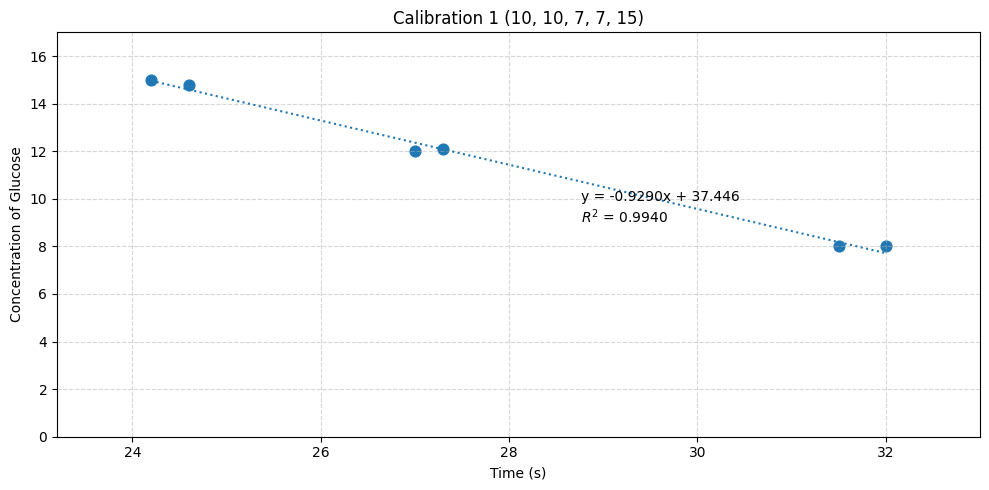

In [229]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your own)
time_s = np.array([24.2, 24.6, 27.0, 27.3, 31.5, 32.0])
conc = np.array([15.0, 14.8, 12.0, 12.1, 8.0, 8.0])

# Linear regression
coeffs = np.polyfit(time_s, conc, 1)
m, b = coeffs
line = m * time_s + b

# R^2
residuals = conc - line
ss_res = np.sum(residuals**2)
ss_tot = np.sum((conc - np.mean(conc))**2)
r2 = 1 - ss_res/ss_tot

# ------------------ Plot ------------------
plt.figure(figsize=(10,5))

# Scatter points
plt.scatter(time_s, conc, s=60)

# Trendline (dotted)
x_fit = np.linspace(time_s.min(), time_s.max(), 200)
plt.plot(x_fit, m*x_fit + b, linestyle='dotted')

# Labels and title
plt.xlabel("Time (s)")
plt.ylabel("Concentration of Glucose")
plt.title("Calibration 1 (10, 10, 7, 7, 15)")

# Text annotation
eq_text = f"y = {m:.4f}x + {b:.3f}\n$R^2$ = {r2:.4f}"
plt.text(time_s.mean()+1, conc.min()+1, eq_text)

# Grid + limits
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(time_s.min()-1, time_s.max()+1)
plt.ylim(0, conc.max()+2)

plt.tight_layout()
plt.show()


In [59]:
zipped_results

{PosixPath('/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/data/orp_data/12C68H20_11_12_2025_r2.csv'): ((0.0,
   -124.875),
  (0.201, -124.875),
  (0.401, -124.875),
  (0.602, -124.75),
  (0.803, -124.75),
  (1.003, -124.875),
  (1.204, 70.875),
  (1.405, 196.0),
  (1.606, 218.25),
  (1.806, 202.625),
  (2.007, 186.5),
  (2.208, 181.5),
  (2.408, 176.625),
  (2.609, 181.5),
  (2.81, 189.75),
  (3.011, 188.75),
  (3.211, 229.0),
  (3.412, 208.75),
  (3.613, 192.0),
  (3.814, 179.625),
  (4.017, 169.875),
  (4.217, 161.75),
  (4.418, 154.125),
  (4.619, 147.75),
  (4.82, 142.125),
  (5.021, 136.75),
  (5.222, 132.25),
  (5.422, 128.125),
  (5.623, 124.25),
  (5.824, 120.5),
  (6.025, 117.0),
  (6.225, 113.75),
  (6.426, 110.625),
  (6.627, 107.5),
  (6.828, 104.625),
  (7.028, 101.875),
  (7.229, 99.125),
  (7.43, 96.375),
  (7.63, 93.625),
  (7.831, 91.125),
  (8.032, 88.5),
  (8.233, 86.0),
  (8.433, 83.75),
  (8.634, 81.625),
  (8.835, 79.5),
  (9.035, 77.5),
  (9.236, 75.87

In [57]:
for key, value in results.items():
    print(value.columns)

Index(['time (ms)', 'mvs'], dtype='object')
Index(['time (ms)', 'mvs'], dtype='object')
Index(['time (ms)', 'mvs'], dtype='object')
Index(['time (ms)', 'mvs'], dtype='object')
Index(['time (ms)', 'mvs'], dtype='object')
Index(['time (ms)', 'mvs'], dtype='object')


In [196]:
from collections import deque

def std_deviation_window_record_data(window, data):
    window_size = window
    arr = deque(maxlen=window_size)
    std_arr = []
    time_arr = []

    for time, mvs in data:
        arr.append(mvs)
        std = np.std(arr, ddof=0)
        print(f'time: {time}, std: {std}')
        std_arr.append(std)
        time_arr.append(time)
    
    return [time_arr, std_arr]
        


def std_deviation_window_alg(window, count, threshold ,data):
    window_size = window
    arr = deque(maxlen=window_size)
    threshold = threshold
    count_threshold = count
    counter = 0
    for time, mvs in data:
        arr.append(mvs)
        if len(arr) == window_size:
            std = np.std(arr, ddof=0)
            if std < threshold:
                counter+= 1
                if counter == count_threshold:
                    return mvs, std, time
                else:
                    counter = 0
    
    return None


def std_deviation_window_alg_two(window, count, threshold ,data):
    #user continous counter instead of total count
    window_size = window
    arr = deque(maxlen=window_size)
    std_arr = deque(maxlen=10)
    threshold = threshold
    count_threshold = count
    counter = 0
    for time, mvs in data:
        arr.append(mvs)
        if len(arr) == window_size:
            std = np.std(arr, ddof=0)
            std_arr.append(std)
            if len(std_arr) == 10:
                if np.std(std_arr) < threshold:
                    counter+= 1
                    if counter == count_threshold:
                        return mvs, std, time
                else:
                    counter = 0
            
    
    return None


class SlidingSlopeLR:
    #using ordinary least squares (OLS)
    def __init__(self, window):
        self.window = window
        self.time_deq = deque(maxlen=window)
        self.mv_deq = deque(maxlen=window)

    def update(self, t, v):
        self.time_deq.append(t)
        self.mv_deq.append(v)

        if len(self.time_deq) < self.window:
            return None

        t_arr = np.fromiter(self.time_deq, dtype=float)
        v_arr = np.fromiter(self.mv_deq, dtype=float)

        t_mean = t_arr.mean()
        v_mean = v_arr.mean()

        numerator = np.sum((t_arr - t_mean) * (v_arr - v_mean))
        denominator = np.sum((t_arr - t_mean)**2)

        return numerator / denominator if denominator != 0 else 0.0

class SlidingSTD:
    def __init__(self, window):
        self.window = window
        self.value_deq = deque(maxlen=window)
    
    def update(self, v):
        self.value_deq.append(v)

        if len(self.value_deq) != self.window:
            return None
        
        std = np.std(self.value_deq)

        return std

def std_deviation_rate_of_change_alg(window=10, rot_window=10, std_threshold=10, rot_threshold=2, hit_threshold=10, data=None):
    slope = SlidingSlopeLR(rot_window)
    std_c = SlidingSTD(window=window)
    arr = deque(maxlen=window)
    hits = 0
    for time, mvs in data:
        arr.append(mvs)
        rot = slope.update(time, mvs)
        std = std_c.update(mvs)
        if std is not None and rot is not None:
            if abs(rot) < rot_threshold and std < std_threshold:
                hits += 1
                if hits == hit_threshold:
                    return mvs, rot, std, time
            else:
                hits = 0
    return None
            





        


In [214]:
path_to_adjusted = str(Path.cwd()) + r'/analysis'
#(window, rot_window, std_threshold, rot_threshold, hit_count)
test_data = ((10, 10, 3, 1, 10),)

for file in Path(path_to_adjusted).iterdir():
    print(str(file))
    df = pd.read_excel(file)
    data = tuple(zip(*(df[col] for col in ['adjusted_time', 'mvs'])))

    for window, rot_window, std_threshold, rot_threshold, hits in test_data:
        res = std_deviation_rate_of_change_alg(window=window, rot_window=rot_window, std_threshold=std_threshold, rot_threshold=rot_threshold, hit_threshold=hits ,data=data)
    #res = std_deviation_window_record_data(30, data)
        if res is None:
            print("did not find a stopping point")
        
        else:
            print(res)
        


/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/8C72H20_11_12_2025_r1.xlsx
(-105.875, -0.8106494467729234, 0.47582165776685703, 50.038)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/12C68H20_11_12_2025_r1.xlsx
(-106.375, -0.792285118026581, 0.45825756949558405, 42.986000000000004)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/15C65H20_11_12_2025_r1.xlsx
(-111.75, -0.751215694192763, 0.43945989578117367, 34.567)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/15C65H20_11_12_2025_r2.xlsx
(-111.25, -0.6524572227346899, 0.3801726581436387, 34.165)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/12C68H20_11_12_2025_r2.xlsx
(-108.625, -0.6936109598185908, 0.4031128874149275, 38.571999999999996)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/8C72H20_11_12_2025_r2.xlsx
(-100.375, -0.9125860359206437, 0.5279678020485719, 50.

In [168]:
path_to_adjusted = str(Path.cwd()) + r'/analysis'
#(window, count, threshold, data)
test_data = ((40, 5, 0.012),)

for file in Path(path_to_adjusted).iterdir():
    print(str(file))
    df = pd.read_excel(file)
    data = tuple(zip(*(df[col] for col in ['adjusted_time', 'mvs'])))
    for window, count, threshold in test_data:
        res = std_deviation_window_alg_two(window, count, threshold, data)
        #res = std_deviation_window_record_data(30, data)

        if res is None:
            print("did not find a stopping point")
        
        else:
            print(res)
    

/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/8C72H20_11_12_2025_r1.xlsx
(-112.125, 0.36357598930622465, 71.93700000000001)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/12C68H20_11_12_2025_r1.xlsx
(-112.875, 0.43739954203794046, 65.09)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/15C65H20_11_12_2025_r1.xlsx
(-117.375, 0.43656149337750805, 53.255)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/15C65H20_11_12_2025_r2.xlsx
(-116.0, 0.43373378932243684, 51.644)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/12C68H20_11_12_2025_r2.xlsx
(-113.5, 0.48451610847834564, 55.045)
/Users/patrickwilson/Desktop/ChemE Repo/Chem-E-2025-2026/algorithm/analysis/8C72H20_11_12_2025_r2.xlsx
(-107.125, 0.3793369008875883, 73.738)


In [ ]:
import matplotlib.pyplot as plt

for file, data in zipped_results.items():
    print(file)
    file2 = str(file).split('/')
    label = file2[-1]
    _, mvs = zip(*data)
    mvs = list(mvs)

    print(len(time)), print(len(std)), print(len(mvs))
    res = std_deviation_window_alg(data)
    time = res[0]
    std = res[1]
    plt.plot(time, std, label=label)
    df = pd.DataFrame({
        "time" : time,
        "std" : std,
        "mvs" : mvs
    })
    df.to_excel(r'./analysis/' + label[:-4] + r'.xlsx', index=False)

plt.show()




In [41]:
import re


def parse_text_file(file):
    arr = [[],[]]
    pattern = r"time:\s*(\S+),\s*mvs:\s*(\S+)"
    with open(file, encoding="utf-8-sig") as f:
        for line in f:
            #format is, time: value, mvs: value
            match = re.search(pattern, line)
            if match:
                time_val = match.group(1)
                mvs_val = match.group(2)
                arr[0].append(float(time_val))
                arr[1].append(float(mvs_val))
            
    return arr


In [42]:
results = {}
for file in Path(path_to_txt_files).iterdir():
    results[str(file)] = parse_text_file(file)
    
    

In [46]:
for file, values in results.items():
    df = pd.DataFrame({
        "time (ms)" : values[0],
        "mvs" : values[1]
    })
    df.to_csv(file)